<a href="https://colab.research.google.com/github/tanvivanani/tanvivanani.github.io/blob/main/Programming_for_Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 COM7024 – Programming for Data Analytics



In [11]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] =(10,5)

In [12]:
# DATA IMPORT & INITIAL INSPECTION

# Load the dataset
df = pd.read_excel("/content/Sales Data_PDA_4052 (1).xlsx")

# Basic structural checks
print(" ~SHAPE ")
print(df.shape)

print("\n ~FIRST 5 ROWS ")
print(df.head())

print("\n ~DATA TYPES & NON-NULL COUNTS ")
print(df.info())

print("\n ~DESCRIPTIVE STATISTICS (numerical) ===")
print(df.describe())

print("\n ~DESCRIPTIVE STATISTICS (categorical) ===")
print(df.describe(include='object'))

print("\n ~MISSING VALUES ===")
print(df.isna().sum())

print("\n ~UNIQUE VALUES PER COLUMN ===")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique — {df[col].unique()[:5]}")

 ~SHAPE 
(1001, 7)

 ~FIRST 5 ROWS 
   order_id customer_id sales_person  priority ship_mode       date  value_£
0      8999        C406        Kelly      High     Plane 2020-06-12  1553.44
1     47872        C100        Kelly  Critical     Plane 2020-06-12   315.40
2     29988        C006        Kelly      High     Lorry 2020-06-12  5075.89
3     37348        C492        Kelly      High     Plane 2020-06-13   520.67
4     28001        C231        Kelly  Critical     Plane 2020-06-14  8431.37

 ~DATA TYPES & NON-NULL COUNTS 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      1001 non-null   int64         
 1   customer_id   1001 non-null   object        
 2   sales_person  1001 non-null   object        
 3   priority      1001 non-null   object        
 4   ship_mode     1001 non-null   object        
 5   date    

In [13]:
#  DATA PRE-PROCESSING

df_raw = df.copy()   # keep raw copy for comparison

# 3.1 ── Data type corrections
print("\nDate dtype:", df['date'].dtype)

# 'priority' contains 'Not Specified' — treat as invalid/NaN
print("\nPriority value counts (before):")
print(df['priority'].value_counts(dropna=False))

df['priority'] =df['priority'].replace('Not Specified', np.nan)
print("\nPriority value counts (after replacing 'Not Specified'):")
print(df['priority'].value_counts(dropna=False))

# 'value_£' — confirm numeric
df['value_£']=pd.to_numeric(df['value_£'],errors='coerce')

# 3.2 ── Missing value check BEFORE imputation
print("\n MISSING VALUES BEFORE IMPUTATION")
print(df.isna().sum())

# Imputation:
# - value_£ (numerical): fill with median
# - priority (categorical): fill with mode
median_value =df['value_£'].median()
mode_priority =df['priority'].mode()[0]

df['value_£'] = df['value_£'].fillna(median_value)
df['priority'] = df['priority'].fillna(mode_priority)

print("\n MISSING VALUES AFTER IMPUTATION")
print(df.isna().sum())

# 3.3 ── Outlier detection and treatment on value_£

# Descriptive stats before
print("\nVALUE_£ STATS BEFORE OUTLIER REMOVAL")
print(df['value_£'].describe())
print("Skewness:", round(df['value_£'].skew(),2))

# IQR method
Q1 = df['value_£'].quantile(0.25)
Q3 = df['value_£'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 -1.5 *IQR
upper_bound = Q3+ 1.5 * IQR

print(f"\nIQR: {IQR:.2f}  |  Lower: {lower_bound:.2f}  |  Upper: {upper_bound:.2f}")

outliers = df[(df['value_£']<lower_bound) | (df['value_£'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")

df_clean = df[(df['value_£']>=lower_bound) & (df['value_£'] <= upper_bound)].copy()

# Descriptive stats after
print("\n VALUE_£ STATS AFTER OUTLIER REMOVAL")
print(df_clean['value_£'].describe())
print("Skewness:",round(df_clean['value_£'].skew(), 2))

print(f"\nRows before:{len(df)}  | Rows after:{len(df_clean)}")


Date dtype: datetime64[ns]

Priority value counts (before):
priority
Critical         221
Not Specified    213
Low              200
High             196
Medium           171
Name: count, dtype: int64

Priority value counts (after replacing 'Not Specified'):
priority
Critical    221
NaN         213
Low         200
High        196
Medium      171
Name: count, dtype: int64

 MISSING VALUES BEFORE IMPUTATION
order_id          0
customer_id       0
sales_person      0
priority        213
ship_mode         0
date              0
value_£           0
dtype: int64

 MISSING VALUES AFTER IMPUTATION
order_id        0
customer_id     0
sales_person    0
priority        0
ship_mode       0
date            0
value_£         0
dtype: int64

VALUE_£ STATS BEFORE OUTLIER REMOVAL
count     1001.000000
mean      1778.402248
std       3457.457206
min          2.450000
25%        134.400000
50%        417.580000
75%       1816.930000
max      27448.240000
Name: value_£, dtype: float64
Skewness: 3.77

IQR: 

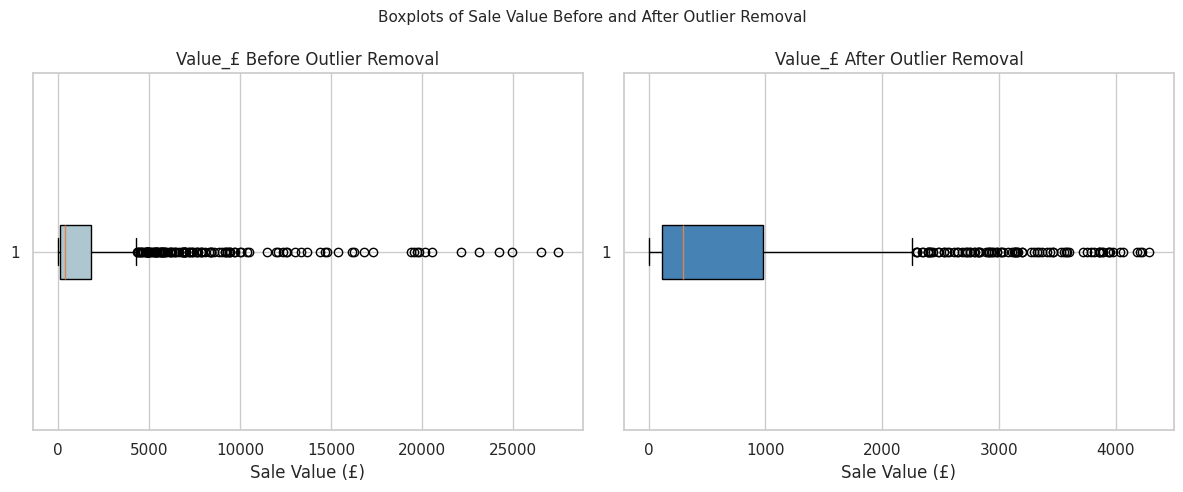

In [14]:
# Boxplot before vs after outlier removal
fig, axes = plt.subplots(1,2,figsize=(12, 5))
axes[0].boxplot(df['value_£'].dropna(), vert=False,patch_artist=True,boxprops=dict(facecolor='#AEC6CF'))
axes[0].set_title("Value_£ Before Outlier Removal",fontsize=12)
axes[0].set_xlabel("Sale Value (£)")

axes[1].boxplot(df_clean['value_£'], vert=False,patch_artist=True,boxprops=dict(facecolor='#4682B4'))
axes[1].set_title("Value_£ After Outlier Removal",fontsize=12)
axes[1].set_xlabel("Sale Value (£)")

plt.suptitle("Boxplots of Sale Value Before and After Outlier Removal", fontsize=11)
plt.tight_layout()
plt.savefig("fig1_boxplot_outlier.png",dpi=150,bbox_inches='tight')
plt.show()

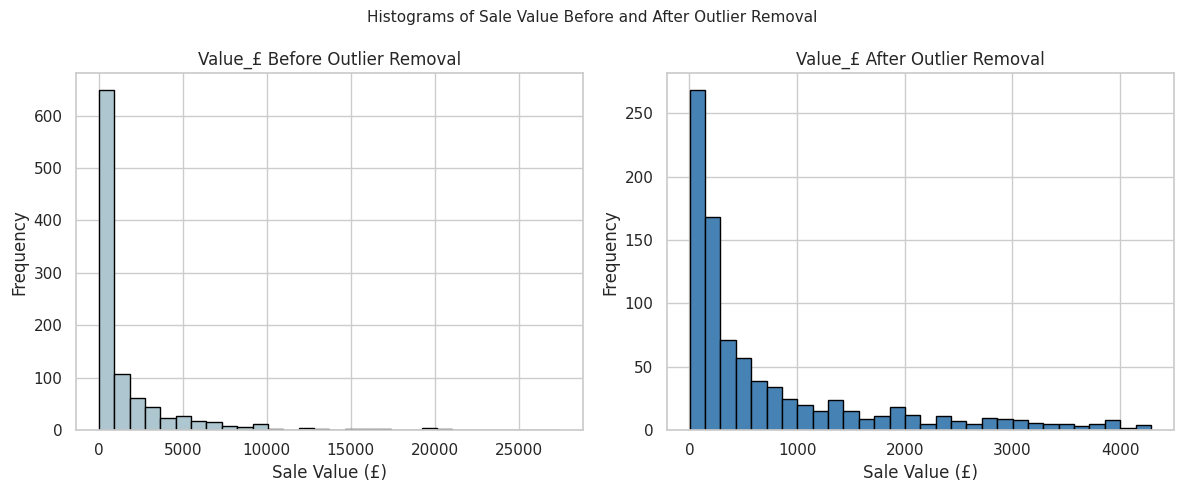

In [15]:
# Histogram before vs after
fig, axes = plt.subplots(1,2,figsize=(12, 5))
axes[0].hist(df['value_£'].dropna(),bins=30,color='#AEC6CF', edgecolor='black')
axes[0].set_title("Value_£ Before Outlier Removal")
axes[0].set_xlabel("Sale Value (£)")
axes[0].set_ylabel("Frequency")

axes[1].hist(df_clean['value_£'],bins=30, color='#4682B4',edgecolor='black')
axes[1].set_title("Value_£ After Outlier Removal")
axes[1].set_xlabel("Sale Value (£)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Histograms of Sale Value Before and After Outlier Removal", fontsize=11)
plt.tight_layout()
plt.savefig("fig2_histogram_outlier.png", dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# EDA
# Add useful time columns
df_clean['year'] =df_clean['date'].dt.year
df_clean['month']= df_clean['date'].dt.month
df_clean['year_month']= df_clean['date'].dt.to_period('M')

# Sales Person distribution
print("\n SALES BY SALESPERSON (count)")
print(df_clean['sales_person'].value_counts())

print("\n TOTAL SALES VALUE BY SALESPERSON")
print(df_clean.groupby('sales_person')['value_£'].sum().sort_values(ascending=False))

print("\n MEAN SALE VALUE BY SALESPERSON ")
print(df_clean.groupby('sales_person')['value_£'].mean().round(2).sort_values(ascending=False))


 SALES BY SALESPERSON (count)
sales_person
Peter    308
Pryia    289
Kelly    282
Name: count, dtype: int64

 TOTAL SALES VALUE BY SALESPERSON
sales_person
Pryia    229755.92
Kelly    226801.95
Peter    200322.99
Name: value_£, dtype: float64

 MEAN SALE VALUE BY SALESPERSON 
sales_person
Kelly    804.26
Pryia    795.00
Peter    650.40
Name: value_£, dtype: float64


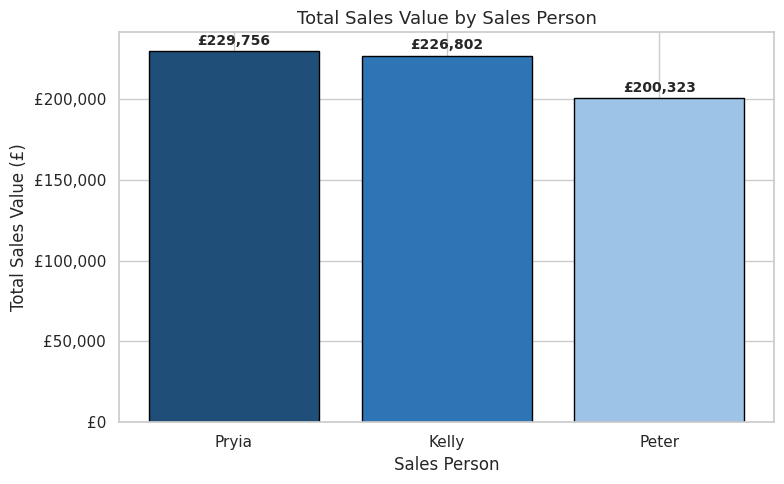

In [17]:
# Total sales value per salesperson (bar chart)
fig, ax = plt.subplots(figsize=(8, 5))
total_by_sp = df_clean.groupby('sales_person')['value_£'].sum().sort_values(ascending=False)
bars = ax.bar(total_by_sp.index, total_by_sp.values,color=['#1f4e79', '#2e75b6', '#9dc3e6'], edgecolor='black')
for bar, val in zip(bars, total_by_sp.values):ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                                                      f'£{val:,.0f}',ha='center',va='bottom',fontsize=10,fontweight='bold')
ax.set_title("Total Sales Value by Sales Person",fontsize=13)
ax.set_xlabel("Sales Person")
ax.set_ylabel("Total Sales Value (£)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig("fig3_total_sales_by_person.png",dpi=150, bbox_inches='tight')
plt.show()

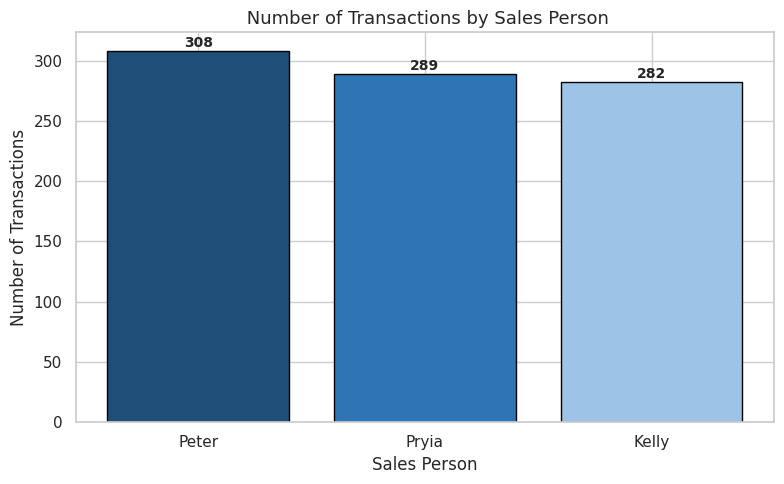

In [18]:
# Number of transactions per salesperson
fig, ax = plt.subplots(figsize=(8, 5))
count_by_sp = df_clean['sales_person'].value_counts()
bars = ax.bar(count_by_sp.index, count_by_sp.values,color=['#1f4e79', '#2e75b6', '#9dc3e6'], edgecolor='black')
for bar, val in zip(bars, count_by_sp.values):ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                                                      str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title(" Number of Transactions by Sales Person", fontsize=13)
ax.set_xlabel("Sales Person")
ax.set_ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig("fig4_transactions_by_person.png",dpi=150,bbox_inches='tight')
plt.show()

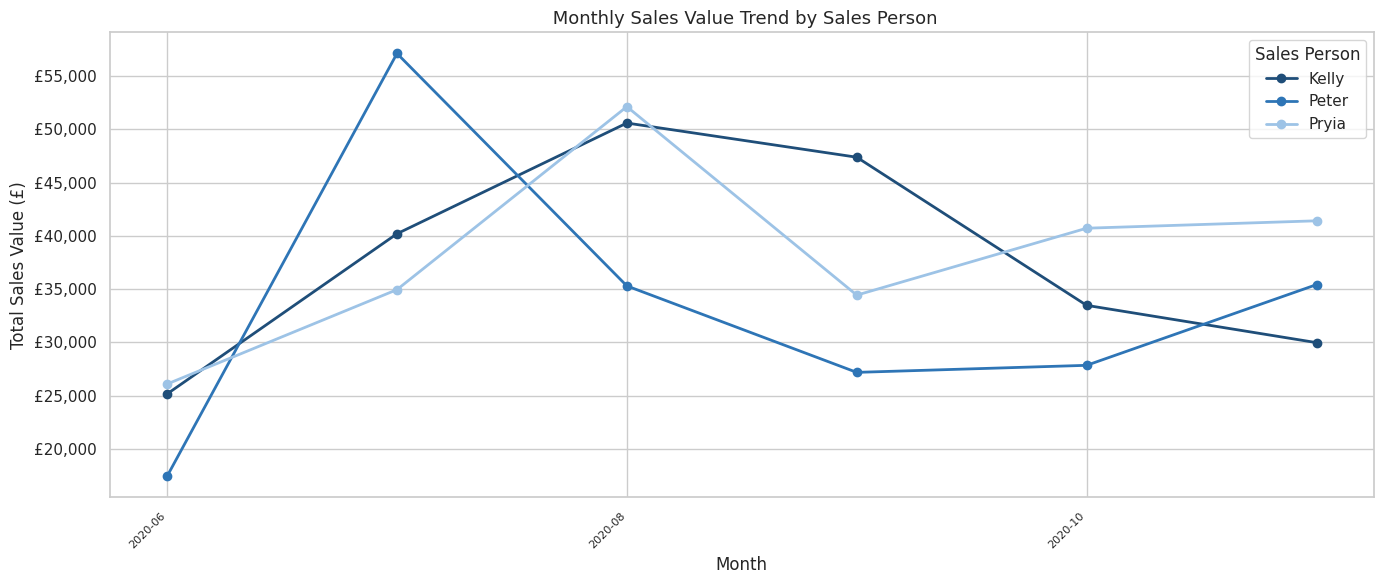

In [19]:
# Monthly sales trend per salesperson
monthly_sp = (df_clean.groupby(['year_month', 'sales_person'])['value_£']
              .sum().reset_index())
monthly_sp['year_month_str'] = monthly_sp['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
for person, colour in zip(['Kelly','Peter', 'Pryia'],['#1f4e79', '#2e75b6', '#9dc3e6']):
    subset = monthly_sp[monthly_sp['sales_person'] == person]
    ax.plot(subset['year_month_str'],subset['value_£'],marker='o',label=person,color=colour,linewidth=2)

# Show every other x-tick to avoid crowding
tick_positions = list(range(0, len(monthly_sp['year_month_str'].unique()), 2))
tick_labels    = [monthly_sp['year_month_str'].unique()[i] for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels,rotation=45,ha='right',fontsize=8)
ax.set_title(" Monthly Sales Value Trend by Sales Person", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales Value (£)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(title="Sales Person")
plt.tight_layout()
plt.savefig("fig5_monthly_trend.png", dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3745/3869251390.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='sales_person',y='value_£',palette=['#1f4e79','#2e75b6','#9dc3e6'],ax=ax)


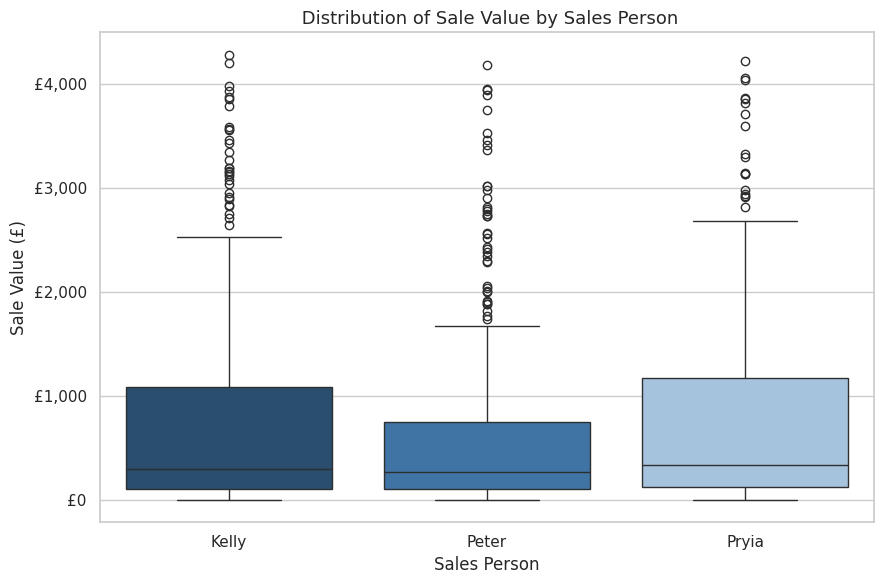

In [20]:
# value distribution per salesperson
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=df_clean, x='sales_person',y='value_£',palette=['#1f4e79','#2e75b6','#9dc3e6'],ax=ax)
ax.set_title(" Distribution of Sale Value by Sales Person",fontsize=13)
ax.set_xlabel("Sales Person")
ax.set_ylabel("Sale Value (£)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig("fig6_boxplot_by_person.png", dpi=150, bbox_inches='tight')
plt.show()

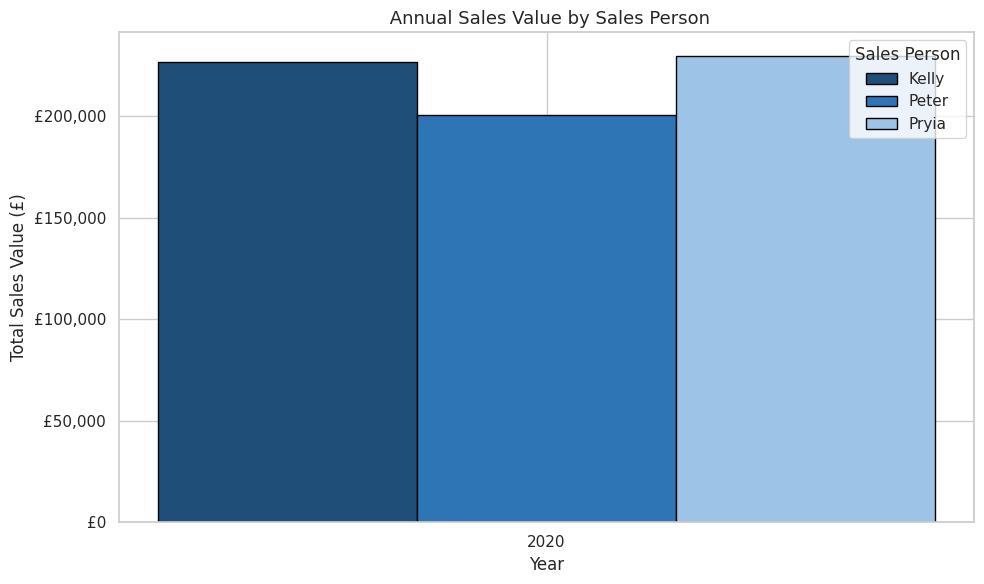

In [21]:
# Annual sales comparison per salesperson ────────
annual_sp = df_clean.groupby(['year','sales_person'])['value_£'].sum().reset_index()
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.25
years = sorted(annual_sp['year'].unique())
people = ['Kelly', 'Peter', 'Pryia']
colours = ['#1f4e79', '#2e75b6', '#9dc3e6']
x = np.arange(len(years))

for i, (person, colour) in enumerate(zip(people, colours)):
    vals = [annual_sp[(annual_sp['year'] == y) & (annual_sp['sales_person'] == person)]['value_£'].sum() for y in years]
    ax.bar(x + i * bar_width, vals,width=bar_width,label=person,color=colour, edgecolor='black')

ax.set_xticks(x + bar_width)
ax.set_xticklabels(years)
ax.set_title(" Annual Sales Value by Sales Person", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Total Sales Value (£)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(title="Sales Person")
plt.tight_layout()
plt.savefig("fig7_annual_sales.png",dpi=150,bbox_inches='tight')
plt.show()

In [26]:
# PRIORITY vs VALUE CORRELATION

#Priority order mapping
priority_order = {'Low': 1,'Medium': 2,'High': 3,'Critical': 4}
df_clean['priority_num']=df_clean['priority'].map(priority_order)

print("\n MEAN SALE VALUE BY PRIORITY")
priority_summary = df_clean.groupby('priority')['value_£'].agg(['mean', 'median', 'count', 'sum'])
priority_summary.columns = ['Mean','Median','Count','Total']
print(priority_summary.round(2))


 MEAN SALE VALUE BY PRIORITY
            Mean  Median  Count      Total
priority                                  
Critical  747.33  271.83    380  283985.92
High      733.17  343.79    167  122439.36
Low       687.97  274.62    182  125209.86
Medium    834.97  342.23    150  125245.72


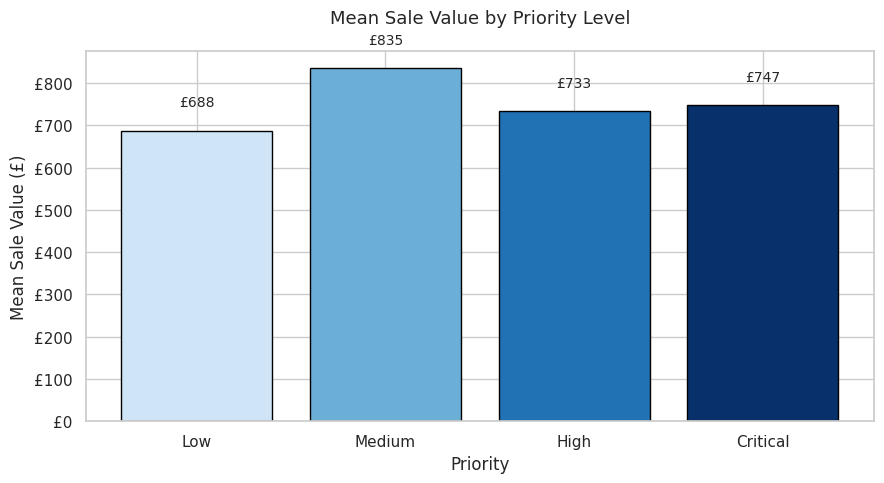

In [30]:
# Mean sale value by priority (bar chart) ────────
priority_mean = (df_clean.groupby('priority')['value_£'].mean()
                 .reindex(['Low','Medium','High', 'Critical']))
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(priority_mean.index, priority_mean.values,
              color=['#d0e4f7','#6baed6','#2171b5','#08306b'],edgecolor='black')
for bar, val in zip(bars, priority_mean.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,f'£{val:,.0f}', ha='center', va='bottom', fontsize=10)
ax.set_title("Mean Sale Value by Priority Level", pad=20,fontsize=13)
ax.set_xlabel("Priority")
ax.set_ylabel("Mean Sale Value (£)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig("fig8_mean_value_by_priority.png", dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3745/615577481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='priority', y='value_£',order=order,palette=['#d0e4f7', '#6baed6', '#2171b5', '#08306b'], ax=ax)


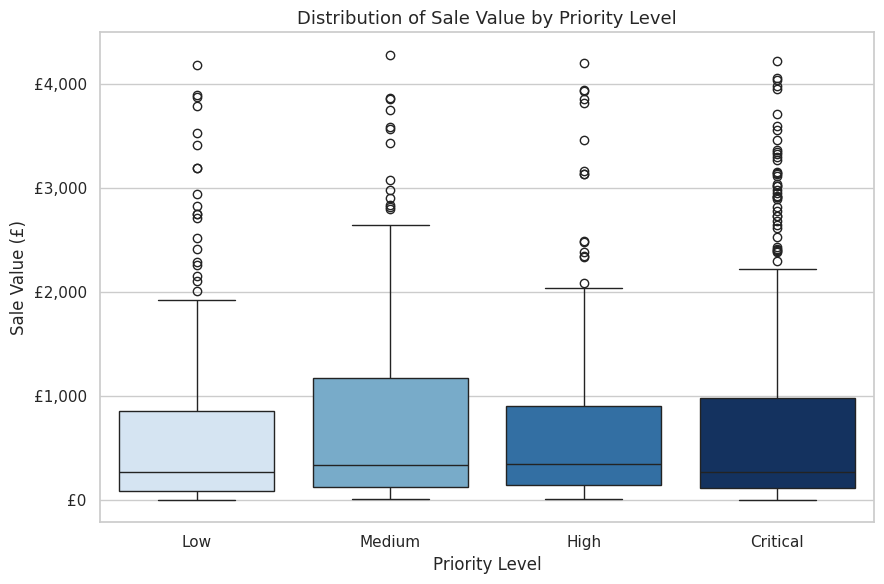

In [28]:
# Boxplot – value distribution per priority ──────
fig, ax = plt.subplots(figsize=(9, 6))
order = ['Low','Medium','High','Critical']
sns.boxplot(data=df_clean, x='priority', y='value_£',order=order,palette=['#d0e4f7', '#6baed6', '#2171b5', '#08306b'], ax=ax)
ax.set_title("Distribution of Sale Value by Priority Level", fontsize=13)
ax.set_xlabel("Priority Level")
ax.set_ylabel("Sale Value (£)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig("fig9_boxplot_priority.png",dpi=150, bbox_inches='tight')
plt.show()

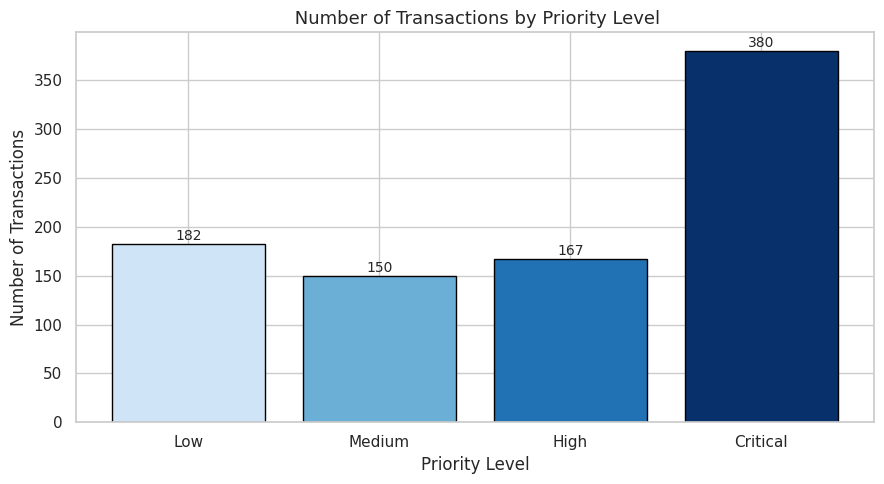

In [29]:
# Count of transactions per priority
fig, ax = plt.subplots(figsize=(9, 5))
priority_counts = df_clean['priority'].value_counts().reindex(['Low', 'Medium', 'High', 'Critical'])
bars = ax.bar(priority_counts.index, priority_counts.values,
              color=['#d0e4f7', '#6baed6', '#2171b5', '#08306b'],edgecolor='black')
for bar, val in zip(bars, priority_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=10)
ax.set_title(" Number of Transactions by Priority Level", fontsize=13)
ax.set_xlabel("Priority Level")
ax.set_ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig("fig10_count_by_priority.png",dpi=150,bbox_inches='tight')
plt.show()

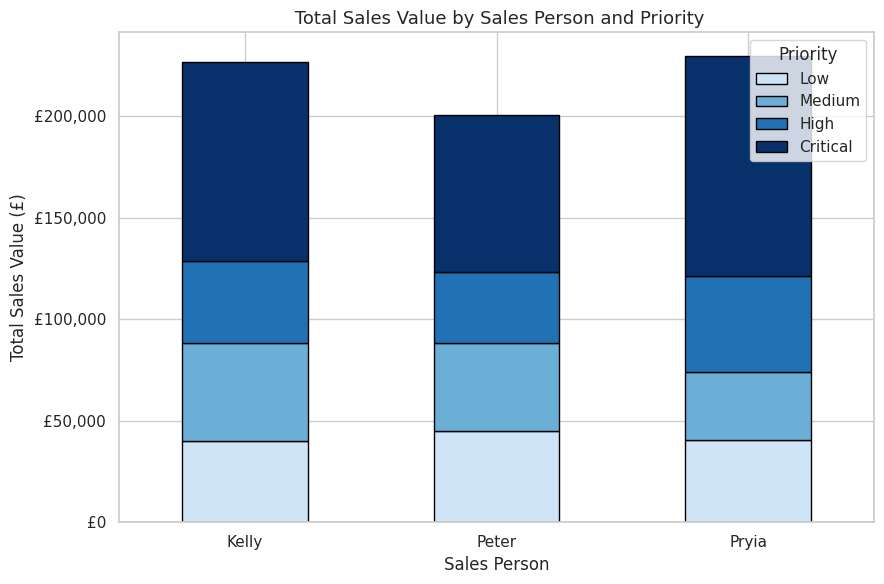

In [ ]:
# Stacked bar – priority breakdown per salesperson
pivot = (df_clean.groupby(['sales_person', 'priority'])['value_£']
         .sum().unstack(fill_value=0)[['Low', 'Medium', 'High', 'Critical']])
pivot.plot(kind='bar',stacked=True,figsize=(9, 6),
           color=['#d0e4f7','#6baed6','#2171b5','#08306b'],edgecolor='black')
plt.title(" Total Sales Value by Sales Person and Priority",fontsize=13)
plt.xlabel("Sales Person")
plt.ylabel("Total Sales Value (£)")
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.legend(title="Priority",loc='upper right')
plt.tight_layout()
plt.savefig("fig11_stacked_priority_person.png",dpi=150,bbox_inches='tight')
plt.show()


=== CORRELATION MATRIX ===
              value_£  priority_num  month_num  year_num
value_£         1.000         0.008     -0.038       NaN
priority_num    0.008         1.000      0.022       NaN
month_num      -0.038         0.022      1.000       NaN
year_num          NaN           NaN        NaN       NaN


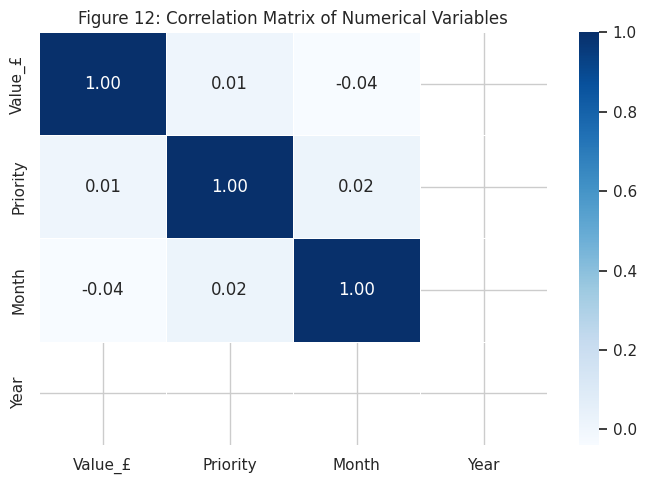

In [ ]:
# Correlation heatmap (numerical variables)
df_clean['month_num']= df_clean['date'].dt.month
df_clean['year_num']  =df_clean['date'].dt.year

corr_cols = ['value_£','priority_num','month_num','year_num']
corr_matrix = df_clean[corr_cols].corr()

print("\n CORRELATION MATRIX")
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.zeros_like(corr_matrix, dtype=bool)
sns.heatmap(corr_matrix,annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax,
            xticklabels=['Value_£','Priority','Month', 'Year'],
            yticklabels=['Value_£','Priority','Month', 'Year'])
ax.set_title(" Correlation Matrix of Numerical Variables", fontsize=12)
plt.tight_layout()
plt.savefig("fig12_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# STATISTICAL TESTS

# Spearman correlation (ordinal priority vs value)
spearman_r, spearman_p = stats.spearmanr(df_clean['priority_num'], df_clean['value_£'])
print(f"\nSpearman Correlation – Priority vs Value_£:")
print(f"  r = {spearman_r:.4f}  |  p-value = {spearman_p:.4f}")
if spearman_p < 0.05:
    print("Statistically significant (p < 0.05)")
else:
    print("Not statistically significant (p ≥ 0.05)")

# Kruskal-Wallis test (non-parametric ANOVA) across priority groups
groups = [df_clean[df_clean['priority'] == p]['value_£'].values
          for p in ['Low', 'Medium', 'High', 'Critical']]
kruskal_stat, kruskal_p =stats.kruskal(*groups)
print(f"\nKruskal-Wallis Test – Value_£ across Priority groups:")
print(f"  H = {kruskal_stat:.4f}  |  p-value = {kruskal_p:.6f}")
if kruskal_p < 0.05:
    print(" Significant difference in sale values across priority levels")

# One-way ANOVA across salesperson groups
sp_groups = [df_clean[df_clean['sales_person'] == p]['value_£'].values
             for p in ['Kelly','Peter','Pryia']]
anova_stat, anova_p = stats.f_oneway(*sp_groups)
print(f"\nOne-Way ANOVA – Value_£ across Sales Persons:")
print(f"  F = {anova_stat:.4f}  |  p-value = {anova_p:.4f}")
if anova_p < 0.05:
    print(" Significant difference in sale values across sales persons")
else:
    print(" No significant difference found")


Spearman Correlation – Priority vs Value_£:
  r = 0.0179  |  p-value = 0.5958
 Not statistically significant (p ≥ 0.05)

Kruskal-Wallis Test – Value_£ across Priority groups:
  H = 3.2569  |  p-value = 0.353683

One-Way ANOVA – Value_£ across Sales Persons:
  F = 2.4201  |  p-value = 0.0895
 No significant difference found


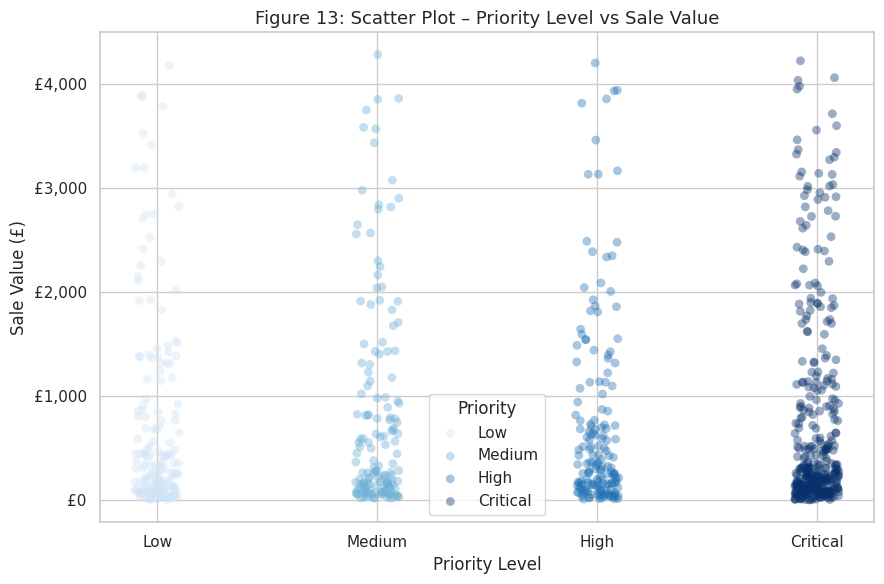

In [ ]:
# Scatter plot – priority_num vs value_£
fig, ax = plt.subplots(figsize=(9, 6))
colours_map = {'Low': '#d0e4f7', 'Medium': '#6baed6', 'High': '#2171b5', 'Critical': '#08306b'}
for pri in ['Low', 'Medium', 'High', 'Critical']:
    subset = df_clean[df_clean['priority'] == pri]
    ax.scatter(subset['priority_num'] + np.random.uniform(-0.1, 0.1, len(subset)),subset['value_£'], alpha=0.4, label=pri,
               color=colours_map[pri], edgecolors='none', s=40)
ax.set_xticks([1,2,3, 4])
ax.set_xticklabels(['Low','Medium', 'High','Critical'])
ax.set_title(" Scatter Plot – Priority Level vs Sale Value",fontsize=13)
ax.set_xlabel("Priority Level")
ax.set_ylabel("Sale Value (£)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(title="Priority")
plt.tight_layout()
plt.savefig("fig13_scatter_priority_value.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ──SUMMARY STATS TABLE ───────────────────────────────────────
print("\n FINAL SUMMARY TABLE ")
summary = df_clean.groupby('sales_person').agg(
    Transactions=('order_id','count'),
    Total_Value=('value_£','sum'),
    Mean_Value=('value_£', 'mean'),
    Median_Value=('value_£', 'median'),
    Std_Dev=('value_£', 'std')).round(2)
print(summary)
print("\n ALL FIGURES SAVED SUCCESSFULLY ")
print("Files: fig1 through fig13 (.png)")


 FINAL SUMMARY TABLE 
              Transactions  Total_Value  Mean_Value  Median_Value  Std_Dev
sales_person                                                              
Kelly                  282    226801.95      804.26        301.48  1047.91
Peter                  308    200322.99      650.40        267.06   883.70
Pryia                  289    229755.92      795.00        339.78   949.66

 ALL FIGURES SAVED SUCCESSFULLY 
Files: fig1 through fig13 (.png)
